# Benchmark for Ablation DQN

In [1]:
import json
import math
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# Assuming these are in your local directory or environment
from rl_service_offline_buffer_training_ablation import offline_rl_agent # Using the updated Balanced DQN Agent

# --- Configuration ---
DATA_DIR = "data"

In [2]:
# Simulation Hyperparameters
TARGET_HUMAN_COUNT = 85
TARGET_BOT_COUNT = 200
SIMULATION_STEP_SECONDS = 10  # How often the RL agent is called (matches frontend)
SESSION_CHUNK_SIZE = int(SIMULATION_STEP_SECONDS * 1000)  # In milliseconds

In [3]:
def update_human_bot_population(human_count=None, bot_count=None):
    global TARGET_HUMAN_COUNT, TARGET_BOT_COUNT, conf
    TARGET_HUMAN_COUNT = random.randint(80, 100) if human_count is None else human_count
    TARGET_BOT_COUNT = random.choice([0, 20, 50, 100, 200, 1000]) if bot_count is None else bot_count

def calculate_reward(user, threat_level):
    """
    Refined reward function for balancing Security vs. UX.
    Weights are normalized so that one 'Happy Human' is roughly 
    equivalent to one 'Caught Bot'.
    """
    reward = 0
    done = False
    
    # Constants for tuning
    MAX_REWARD = 50.0        # Baseline for a 'Perfect' action
    LEAKAGE_PENALTY = -150.0 # Bot got through (Critical Failure)
    FRICTION_BASE = 2.0      # Sensitivity to human annoyance
    
    if user.is_bot:
        if threat_level > user.bot_strength:
            # Bot CAUGHT
            overkill = (threat_level - user.bot_strength)
            reward = MAX_REWARD - (overkill * 2.5) # Penalty for using high level on weak bot
            done = True
            user.reset_session()
        else:
            # Bot SURVIVED / LEAKED
            gap = user.bot_strength - threat_level
            reward = LEAKAGE_PENALTY - (gap * 5.0)
            user.captchas_solved += 1
    else:
        # HUMAN logic
        if threat_level == 0:
            reward = MAX_REWARD # Perfect score for zero friction
        else:
            # Level 1 is annoying, Level 10 is session-ending frustration
            frustration = math.pow(FRICTION_BASE, threat_level)
            reward = (MAX_REWARD / 2.0) - frustration
            
        user.captchas_solved += 1
        
        # Check if human gave up (Simulated patience)
        if threat_level == 10 or random.random() * (threat_level - 6) > 0.5:
            done = True # Human abandoned site due to high friction

    return reward, done


def load_session_data(data_dir):
    """Loads all human and bot raw data files."""
    human_sessions = []
    bot_sessions = []
    print(f"Loading raw session data from {data_dir}...")
    for filename in os.listdir(data_dir):
        if not filename.endswith('.json'): continue
        filepath = os.path.join(data_dir, filename)
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
            if filename.startswith('human'):
                human_sessions.append(data)
            elif filename.startswith('bot'):
                bot_sessions.append(data)
        except Exception as e:
            print(f"Warning: Could not load or parse {filename}. Error: {e}")

    print(f"Loaded {len(human_sessions)} human sessions and {len(bot_sessions)} bot sessions.")
    if not human_sessions or not bot_sessions:
        print("Error: Not enough data to run simulation. Please run bot simulator and browse site.")
        exit()
    return human_sessions, bot_sessions


def perturb_mouse_data(movements):
    """Creates a 'new' user by slightly altering existing mouse data."""
    if not movements: return []
    # Add small random noise to each coordinate
    noise_x = random.randint(-5//5, 5//5)
    noise_y = random.randint(-5//5, 5//5)
    return [{**m, 'x': m['x'] + noise_x, 'y': m['y'] + noise_y, 'timestamp': m['timestamp']} for m in movements]


def get_session_chunks(session_data, chunk_size_ms, target_chunks_size=12):
    """Splits a full session's mouse data into 10-second (step) chunks."""
    start_time = session_data['timestamps']['start']
    movements = session_data.get('mouse_movements', [])
    if not movements: return [[]]  # Return one empty chunk

    chunks = []
    current_chunk = []
    chunk_end_time = start_time + chunk_size_ms

    for move in movements:
        if move['timestamp'] <= chunk_end_time:
            current_chunk.append(move)
        else:
            chunks.append(current_chunk)
            if len(chunks) == target_chunks_size:
                return chunks
            # Handle multiple empty steps
            while move['timestamp'] > chunk_end_time + chunk_size_ms:
                chunks.append([])
                if len(chunks) == target_chunks_size:
                    return chunks
                chunk_end_time += chunk_size_ms

            current_chunk = [move]
            chunk_end_time += chunk_size_ms

    chunks.append(current_chunk)  # Add the last chunk
    if len(chunks) < target_chunks_size:
        chunks = chunks + get_session_chunks(session_data, chunk_size_ms, target_chunks_size=target_chunks_size - len(chunks))
    return chunks


# --- Simulation Classes ---

class SimulatedUser:
    def __init__(self, base_session_data, is_bot):
        self.is_bot = is_bot
        self.client_id = f"{'bot' if is_bot else 'human'}_{random.randint(10000, 99999)}"
        self.captchas_solved = 0
        self.last_captcha_solved = 0
        self.done = False
        self.last_humanity_score = 0.5
        self.average_humanity_score = 0.5
        self.n_humanity_score = 0
        self.bot_strength = random.randint(0, 9) if is_bot else None

        # Perturb and chunk the data to create a new, unique session
        perturbed_movements = perturb_mouse_data(base_session_data.get('mouse_movements', []))
        perturbed_session = {**base_session_data, 'mouse_movements': perturbed_movements}
        self.session_chunks = get_session_chunks(perturbed_session, SESSION_CHUNK_SIZE)
        self.current_chunk_index = 0

    def get_step_data(self):
        if self.current_chunk_index >= len(self.session_chunks):
            self.done = True
            return None
        chunk = self.session_chunks[self.current_chunk_index]
        self.current_chunk_index += 1
        return chunk
    
    def update_stats(self, h_score):
        if h_score is not None:
            self.last_humanity_score = h_score
            self.average_humanity_score = (self.average_humanity_score * self.n_humanity_score + h_score) / (self.n_humanity_score + 1)
            self.n_humanity_score += 1

    def reset_session(self):
        self.captchas_solved = 0
        self.done = True

In [5]:
# MODEL_SAVE_PATH = "models/ablation/2/offline_rl_model_0_200.pt"
# MODEL_SAVE_PATH = "models/ablation/2/best_model.pt"
MODEL_SAVE_PATH = "models/ablation/best_model_-217.27.pt"

offline_rl_agent.load_model(MODEL_SAVE_PATH)

update_human_bot_population(human_count=100, bot_count=100)

Loading offline model from models/ablation/best_model_-217.27.pt...
Offline model loaded successfully.


In [6]:
# Track population over time
human_counts = []
bot_counts = []
timestep_counts = []
current_timestep = 0

# This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
pending_experiences = {}
episode_reward = 0

print("--- Starting Offline Training Simulator ---")
base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

update_human_bot_population(human_count=85, bot_count=20)

# 1. Create the population for this episode
print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
active_users = []
for _ in range(TARGET_HUMAN_COUNT):
    active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
for _ in range(TARGET_BOT_COUNT):
    active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
    
random.shuffle(active_users)

human_count = TARGET_HUMAN_COUNT
bot_count = TARGET_BOT_COUNT

while active_users:
    # ---- Population tracking per timestep ----
    human_count = sum(1 for u in active_users if not u.is_bot)
    bot_count = sum(1 for u in active_users if u.is_bot)
    
    human_counts.append(human_count)
    bot_counts.append(bot_count)
    timestep_counts.append(current_timestep)
    current_timestep += 1
    
    server_total_users = len(active_users)
    server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

    next_active_users = []
    new_pending_experiences = {}

    for user in active_users:
        # 1. Get user's data and calculate current state s_t
        mouse_data = user.get_step_data()
        
        # if user.is_bot and humanity_score is not None:
        #     humanity_score = humanity_score ** 4
            # print(humanity_score)

        s_t = [
            user.captchas_solved,
            user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
            # server_req_rate_per_min,
            server_total_users
        ]

        # 2. Finalize the experience from step t-1
        if user.client_id in pending_experiences:
            prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
            s_prime = s_t  # The current state is the "next_state" for the previous action

            # Store the *completed* transition from t-1
            # offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done, user.is_bot)
            episode_reward += prev_r

        # 3. Check if user's session ended *naturally* (ran out of data)
        if user.done:
            continue  # User is done, no new action to take

        # 4. User is still active, take a new action (a_t)
        a_t = offline_rl_agent.select_action(s_t)
        
        # a_t = 10 if humanity_score > 0.5 else 0   
        # a_t = int(humanity_score * 10)

        # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
        r_t, done_t = calculate_reward(user, a_t)

        # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

        # 6. Store this new experience
        if done_t:
            # This is a terminal state (e.g., bot was killed).
            # We have the full experience now. Store it immediately.
            s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
            # offline_rl_agent.remember(s_t, a_t, r_t, s_prime, True, user.is_bot)
            episode_reward += r_t
            
            # if user.is_bot:
            #     bot_count -= 1
            
        else:
            # This is a non-terminal state.
            # Store it as pending, waiting for s' from the next step.
            new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
            user.last_captcha_solved = a_t
            next_active_users.append(user)  # User continues

    
    if not next_active_users:
        print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
        print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")

    # --- End of Step ---
    active_users = next_active_users
    pending_experiences = new_pending_experiences

    if not active_users:
        print(f"All users finished.")
        
print(f"Net reward: {episode_reward}")
print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 85 humans, 20 bots
Final remaining humans: 82
Final remaining bots: 9
All users finished.
Net reward: -3479.5
Normalized reward: -33.14


In [54]:
MODEL_SAVE_PATH = "models/ablation/3/offline_rl_model_0_1373.pt"
# MODEL_SAVE_PATH = "models/ablation/3/best_model_-217.27.pt"
# MODEL_SAVE_PATH = "models/ablation/3/best_model.pt"

offline_rl_agent.load_model(MODEL_SAVE_PATH)

update_human_bot_population(human_count=100, bot_count=100)

Loading offline model from models/ablation/3/offline_rl_model_0_1373.pt...
Offline model loaded successfully.


--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 0 bots
Final remaining humans: 98
Final remaining bots: 0
All users finished.
Total Reward: 18735.00 | Avg: 15.66 | Avg Human: 15.66 | Avg Bot: 0.00
Average Session Rewards::: Mean: 187.35 | Human: 187.35 | Bot: 0.00
Net reward: 18735.0
Normalized reward: 187.35





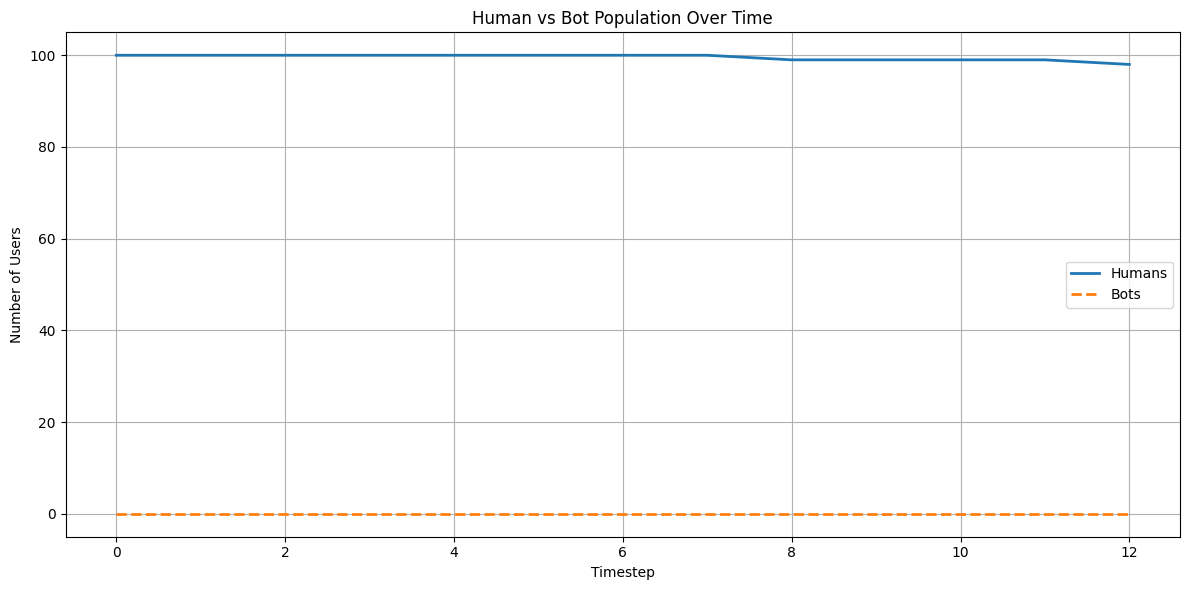

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 20 bots
Final remaining humans: 99
Final remaining bots: 12
All users finished.
Total Reward: -4146.00 | Avg: -3.07 | Avg Human: 16.34 | Avg Bot: -155.92
Average Session Rewards::: Mean: -34.55 | Human: 195.54 | Bot: -1185.00
Net reward: -4146.0
Normalized reward: -34.55





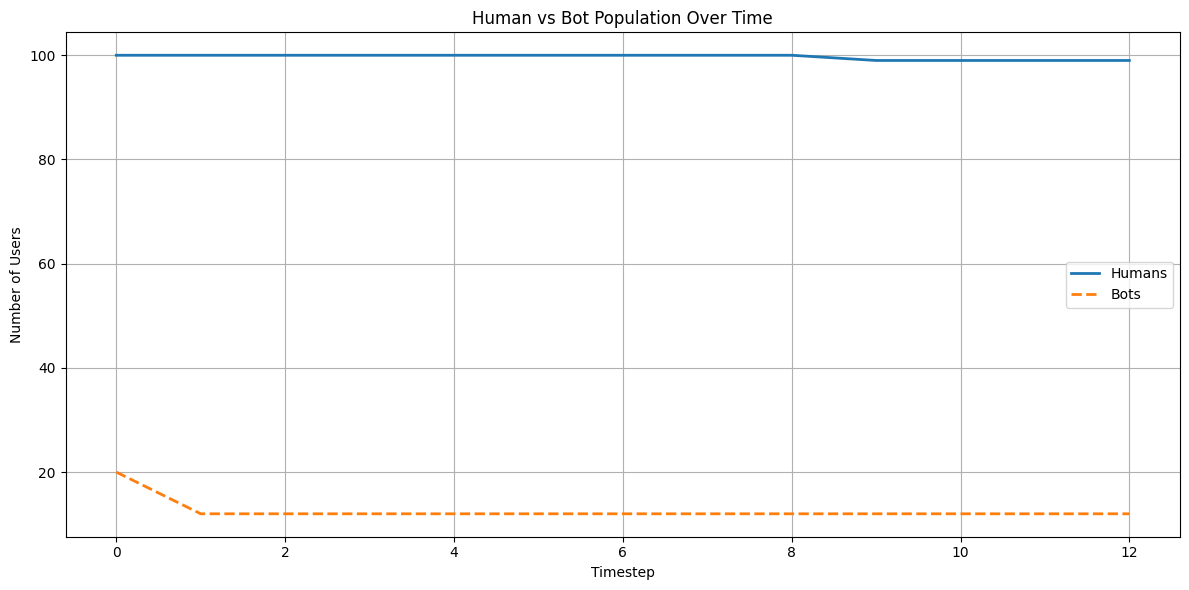

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 100 bots
Final remaining humans: 99
Final remaining bots: 66
All users finished.
Total Reward: -113332.00 | Avg: -55.69 | Avg Human: 16.49 | Avg Bot: -157.55
Average Session Rewards::: Mean: -566.66 | Human: 196.43 | Bot: -1329.75
Net reward: -113332.0
Normalized reward: -566.66





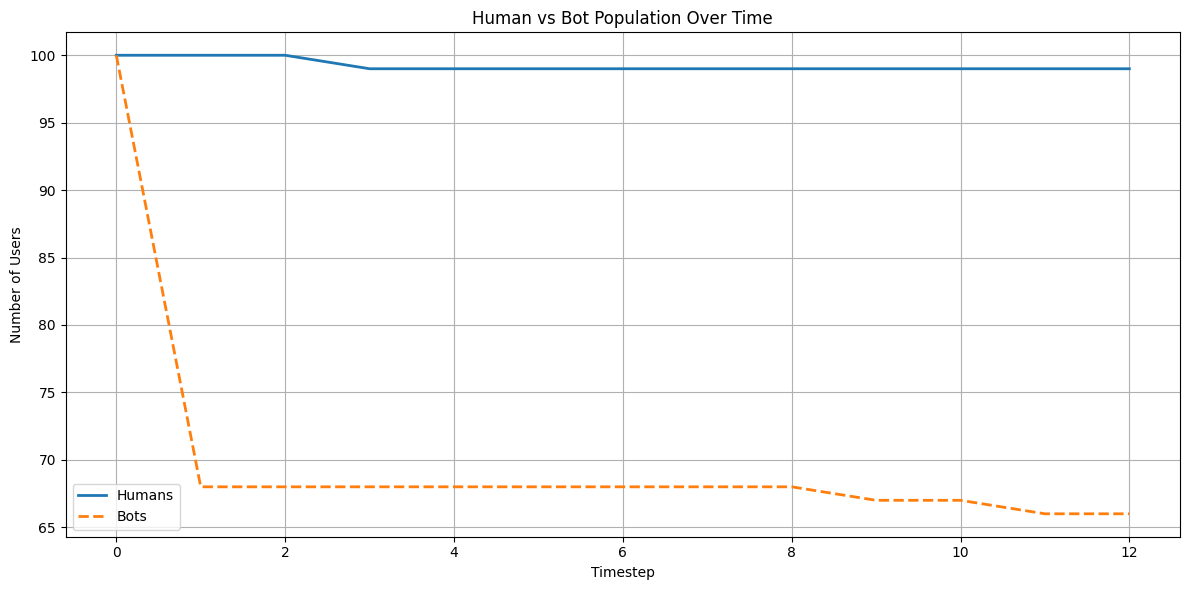

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 200 bots
Final remaining humans: 99
Final remaining bots: 136
All users finished.
Total Reward: -247849.00 | Avg: -84.97 | Avg Human: 16.78 | Avg Bot: -155.37
Average Session Rewards::: Mean: -826.16 | Human: 200.16 | Bot: -1339.33
Net reward: -247849.0
Normalized reward: -826.16





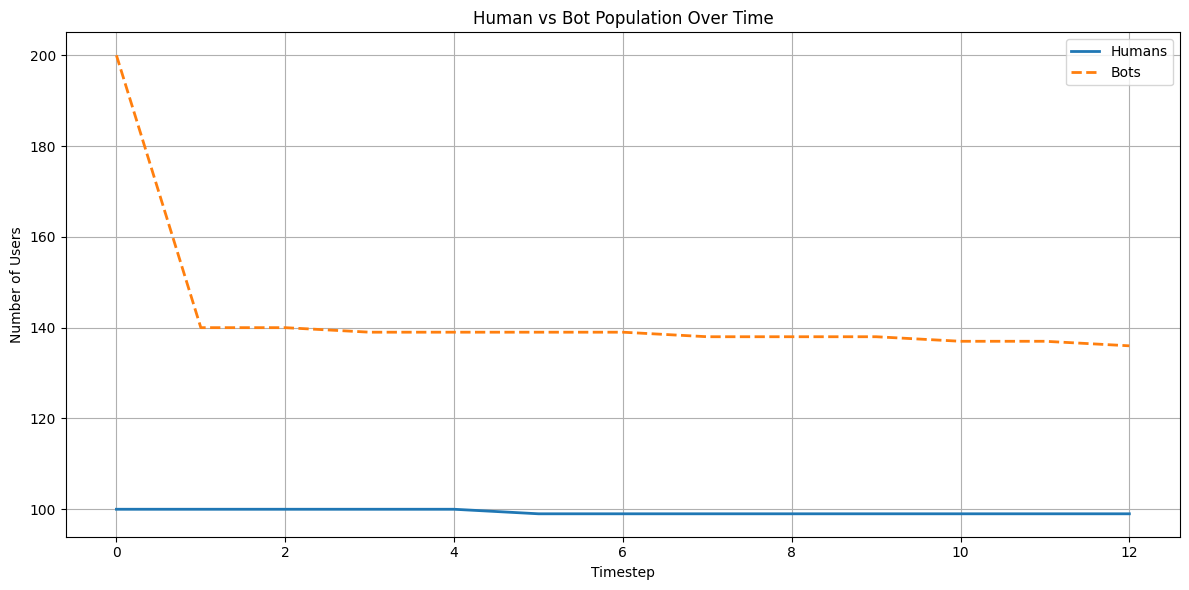

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 500 bots
Final remaining humans: 98
Final remaining bots: 339
All users finished.
Total Reward: -657965.00 | Avg: -119.65 | Avg Human: 16.49 | Avg Bot: -157.21
Average Session Rewards::: Mean: -1096.61 | Human: 195.75 | Bot: -1355.80
Net reward: -657965.0
Normalized reward: -1096.61





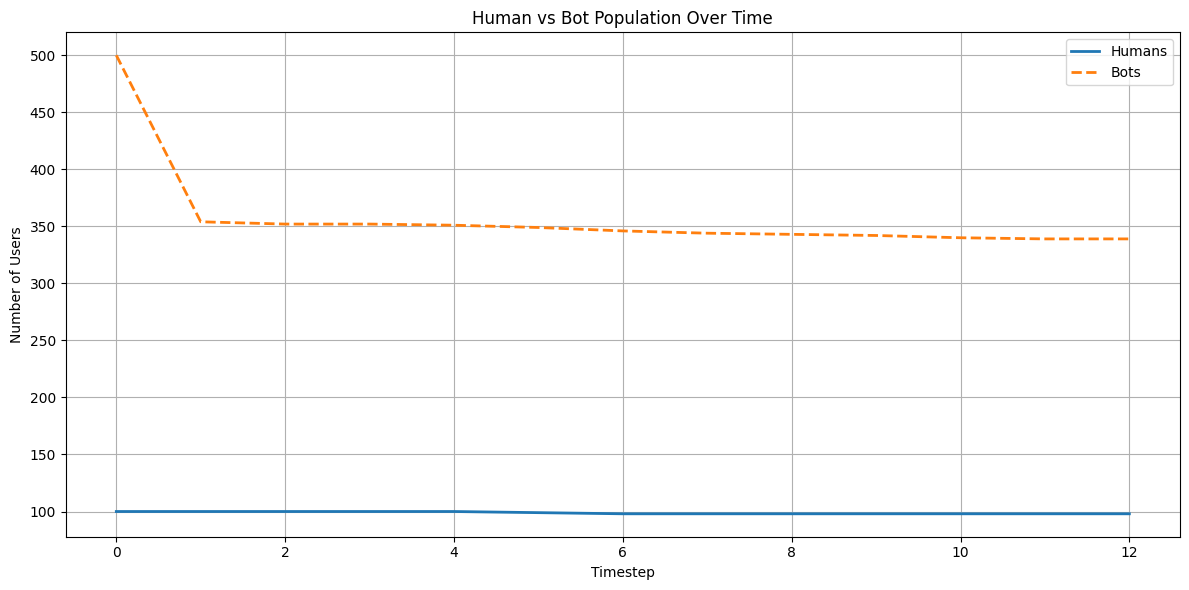

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 1000 bots
Final remaining humans: 96
Final remaining bots: 672
All users finished.
Total Reward: -1332891.50 | Avg: -136.50 | Avg Human: 14.58 | Avg Bot: -157.01
Average Session Rewards::: Mean: -1211.72 | Human: 170.61 | Bot: -1349.48
Net reward: -1332891.5
Normalized reward: -1211.72





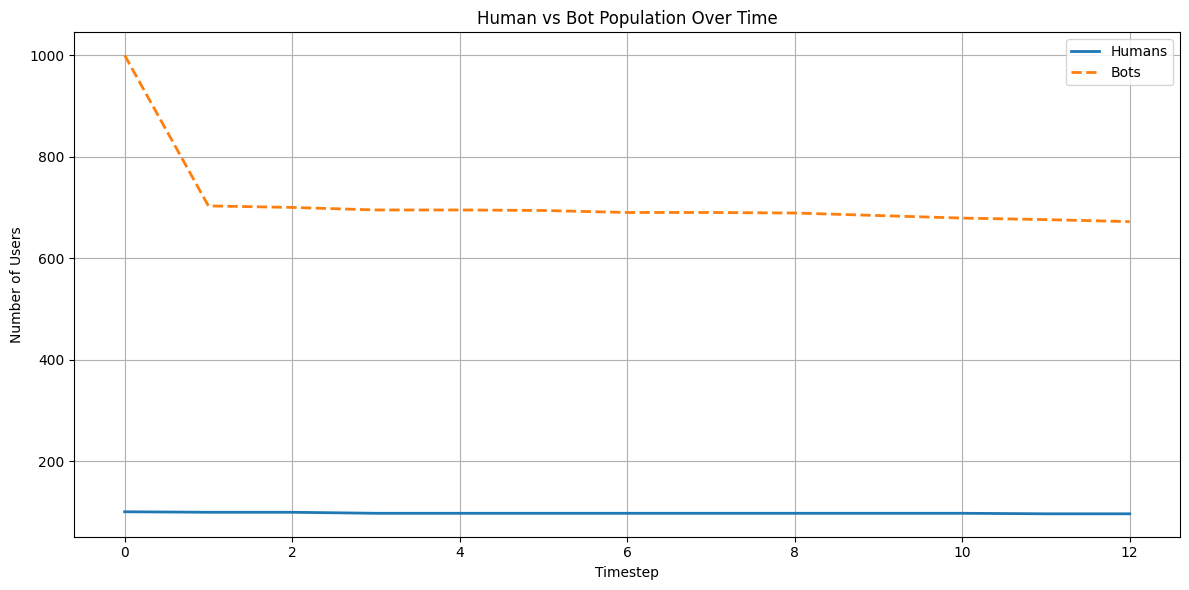

In [55]:
bot_counts_lst = [0, 20, 100, 200, 500, 1000]
h_count = 100

dct = dict()

for b_count in bot_counts_lst:
    update_human_bot_population(human_count=h_count, bot_count=b_count)

    # Track population over time
    human_counts = []
    bot_counts = []
    timestep_counts = []
    current_timestep = 0

    # This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
    pending_experiences = {}
    episode_reward = 0
    global_step_counter = 0
    episode_h_step_counter = 0
    episode_b_step_counter = 0
    episode_human_reward = 0
    episode_bot_reward = 0

    print("--- Starting Offline Training Simulator ---")
    base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

    # update_human_bot_population(human_count=85, bot_count=200)

    # 1. Create the population for this episode
    print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
    active_users = []
    for _ in range(TARGET_HUMAN_COUNT):
        active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
    for _ in range(TARGET_BOT_COUNT):
        active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
        
    random.shuffle(active_users)

    human_count = TARGET_HUMAN_COUNT
    bot_count = TARGET_BOT_COUNT

    while active_users:
        # ---- Population tracking per timestep ----
        human_count = sum(1 for u in active_users if not u.is_bot)
        bot_count = sum(1 for u in active_users if u.is_bot)
        
        human_counts.append(human_count)
        bot_counts.append(bot_count)
        timestep_counts.append(current_timestep)
        current_timestep += 1
        
        server_total_users = len(active_users)
        server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

        next_active_users = []
        new_pending_experiences = {}

        for user in active_users:
            # 1. Get user's data and calculate current state s_t
            mouse_data = user.get_step_data()

            s_t = [
                user.captchas_solved,
                user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
                # server_req_rate_per_min,
                server_total_users
            ]

            # 2. Finalize the experience from step t-1
            if user.client_id in pending_experiences:
                prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
                s_prime = s_t  # The current state is the "next_state" for the previous action

                # Store the *completed* transition from t-1
                # offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done, user.is_bot)
                episode_reward += prev_r

            # 3. Check if user's session ended *naturally* (ran out of data)
            if user.done:
                continue  # User is done, no new action to take

            # 4. User is still active, take a new action (a_t)
            a_t = offline_rl_agent.select_action(s_t)
            
            # a_t = 10 if humanity_score > 0.5 else 0   
            # a_t = int(humanity_score * 10)

            # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
            r_t, done_t = calculate_reward(user, a_t)

            if user.is_bot:
                episode_bot_reward += r_t
                episode_b_step_counter += 1
            else:
                episode_human_reward += r_t
                episode_h_step_counter += 1
                
            global_step_counter += 1

            # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

            # 6. Store this new experience
            if done_t:
                # This is a terminal state (e.g., bot was killed).
                # We have the full experience now. Store it immediately.
                s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
                # offline_rl_agent.remember(s_t, a_t, r_t, s_prime, True, user.is_bot)
                episode_reward += r_t
                
                # if user.is_bot:
                #     bot_count -= 1
                
            else:
                # This is a non-terminal state.
                # Store it as pending, waiting for s' from the next step.
                new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
                user.last_captcha_solved = a_t
                next_active_users.append(user)  # User continues

        
        if not next_active_users:
            print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
            print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")

        # --- End of Step ---
        active_users = next_active_users
        pending_experiences = new_pending_experiences

        if not active_users:
            print(f"All users finished.")

    # Metrics logging...
    avg_rew = episode_reward / (episode_h_step_counter + episode_b_step_counter)   # (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_human_rew = episode_human_reward / episode_h_step_counter
    avg_bot_rew = episode_bot_reward / episode_b_step_counter if episode_b_step_counter else 0
    print(f"Total Reward: {episode_reward:.2f} | Avg: {avg_rew:.2f} | Avg Human: {avg_human_rew:.2f} | Avg Bot: {avg_bot_rew:.2f}")
        
    avg_session_rew = episode_reward / (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_h_session_rew = episode_human_reward / (TARGET_HUMAN_COUNT)
    avg_b_session_rew = episode_bot_reward / TARGET_BOT_COUNT if TARGET_BOT_COUNT else 0
    print(f"Average Session Rewards::: Mean: {avg_session_rew:.2f} | Human: {avg_h_session_rew:.2f} | Bot: {avg_b_session_rew:.2f}")

            
    print(f"Net reward: {episode_reward}")
    print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")
    print("\n\n")

    dct[b_count] = {
        "timesteps": timestep_counts,
        "human_counts": human_counts,
        "bot_counts": bot_counts
    }

    plt.figure(figsize=(12, 6))

    plt.plot(timestep_counts, human_counts,
            label="Humans",
            linestyle="-",
            linewidth=2)

    plt.plot(timestep_counts, bot_counts,
            label="Bots",
            linestyle="--",
            linewidth=2)

    plt.xlabel("Timestep")
    plt.ylabel("Number of Users")
    plt.title("Human vs Bot Population Over Time")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

with open("eval_dqn_ablation.json", "w") as f:
    json.dump(dct, f)

In [39]:
bot_counts_lst = [0, 20, 100, 200, 500, 1000]
h_count = 100

SAMPLE_SIZE = 10

dct = dict()

for b_count in bot_counts_lst:
    update_human_bot_population(human_count=h_count, bot_count=b_count)

    for i in range(SAMPLE_SIZE):
        random.seed(i)
        
        # Track population over time
        human_counts = []
        bot_counts = []
        timestep_counts = []
        current_timestep = 0

        # This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
        pending_experiences = {}
        episode_reward = 0
        global_step_counter = 0
        episode_h_step_counter = 0
        episode_b_step_counter = 0
        episode_human_reward = 0
        episode_bot_reward = 0

        print("--- Starting Offline Training Simulator ---")
        base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

        # update_human_bot_population(human_count=85, bot_count=200)

        # 1. Create the population for this episode
        print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
        active_users = []
        for _ in range(TARGET_HUMAN_COUNT):
            active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
        for _ in range(TARGET_BOT_COUNT):
            active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
            
        random.shuffle(active_users)

        human_count = TARGET_HUMAN_COUNT
        bot_count = TARGET_BOT_COUNT

        while active_users:
            # ---- Population tracking per timestep ----
            human_count = sum(1 for u in active_users if not u.is_bot)
            bot_count = sum(1 for u in active_users if u.is_bot)
            
            human_counts.append(human_count)
            bot_counts.append(bot_count)
            timestep_counts.append(current_timestep)
            current_timestep += 1
            
            server_total_users = len(active_users)
            server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

            next_active_users = []
            new_pending_experiences = {}

            for user in active_users:
                # 1. Get user's data and calculate current state s_t
                mouse_data = user.get_step_data()

                s_t = [
                    user.captchas_solved,
                    user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
                    # server_req_rate_per_min,
                    server_total_users
                ]

                # 2. Finalize the experience from step t-1
                if user.client_id in pending_experiences:
                    prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
                    s_prime = s_t  # The current state is the "next_state" for the previous action

                    # Store the *completed* transition from t-1
                    # offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done, user.is_bot)
                    episode_reward += prev_r

                # 3. Check if user's session ended *naturally* (ran out of data)
                if user.done:
                    continue  # User is done, no new action to take

                # 4. User is still active, take a new action (a_t)
                a_t = offline_rl_agent.select_action(s_t)
                
                # a_t = 10 if humanity_score > 0.5 else 0   
                # a_t = int(humanity_score * 10)

                # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
                r_t, done_t = calculate_reward(user, a_t)

                if user.is_bot:
                    episode_bot_reward += r_t
                    episode_b_step_counter += 1
                else:
                    episode_human_reward += r_t
                    episode_h_step_counter += 1
                    
                global_step_counter += 1

                # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

                # 6. Store this new experience
                if done_t:
                    # This is a terminal state (e.g., bot was killed).
                    # We have the full experience now. Store it immediately.
                    s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
                    # offline_rl_agent.remember(s_t, a_t, r_t, s_prime, True, user.is_bot)
                    episode_reward += r_t
                    
                    # if user.is_bot:
                    #     bot_count -= 1
                    
                else:
                    # This is a non-terminal state.
                    # Store it as pending, waiting for s' from the next step.
                    new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
                    user.last_captcha_solved = a_t
                    next_active_users.append(user)  # User continues

            
            if not next_active_users:
                print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
                print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")
                remaining_humans = sum(1 for u in active_users if not u.is_bot)
                remaining_bots = sum(1 for u in active_users if u.is_bot)

            # --- End of Step ---
            active_users = next_active_users
            pending_experiences = new_pending_experiences

            if not active_users:
                print(f"All users finished.")

        # Metrics logging...
        avg_rew = episode_reward / (episode_h_step_counter + episode_b_step_counter)   # (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
        avg_human_rew = episode_human_reward / episode_h_step_counter
        avg_bot_rew = episode_bot_reward / episode_b_step_counter if episode_b_step_counter else 0
        print(f"Total Reward: {episode_reward:.2f} | Avg: {avg_rew:.2f} | Avg Human: {avg_human_rew:.2f} | Avg Bot: {avg_bot_rew:.2f}")
            
        avg_session_rew = episode_reward / (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
        avg_h_session_rew = episode_human_reward / (TARGET_HUMAN_COUNT)
        avg_b_session_rew = episode_bot_reward / TARGET_BOT_COUNT if TARGET_BOT_COUNT else 0
        print(f"Average Session Rewards::: Mean: {avg_session_rew:.2f} | Human: {avg_h_session_rew:.2f} | Bot: {avg_b_session_rew:.2f}")

                
        print(f"Net reward: {episode_reward}")
        print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")
        print("\n\n")

        dct[b_count] = {
            "session_rew": dct.get(b_count, {}).get("session_rew", []) + [avg_session_rew],
            "h_session_rew": dct.get(b_count, {}).get("h_session_rew", []) + [avg_h_session_rew],
            "b_session_rew": dct.get(b_count, {}).get("b_session_rew", []) + [avg_b_session_rew],
            "step_rew": dct.get(b_count, {}).get("step_rew", []) + [avg_rew],
            "h_step_rew": dct.get(b_count, {}).get("h_step_rew", []) + [avg_human_rew],
            "b_step_rew": dct.get(b_count, {}).get("b_step_rew", []) + [avg_bot_rew],
            "rem_h": dct.get(b_count, {}).get("rem_h", []) + [remaining_humans],
            "rem_b": dct.get(b_count, {}).get("rem_b", []) + [remaining_bots],
        }

# with open("eval_dqn_ablation.json", "w") as f:
#     json.dump(dct, f)

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 0 bots
Final remaining humans: 96
Final remaining bots: 0
All users finished.
Total Reward: 17340.00 | Avg: 14.69 | Avg Human: 14.69 | Avg Bot: 0.00
Average Session Rewards::: Mean: 173.40 | Human: 173.40 | Bot: 0.00
Net reward: 17340.0
Normalized reward: 173.40



--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 0 bots
Final remaining humans: 99
Final remaining bots: 0
All users finished.
Total Reward: 19656.00 | Avg: 16.39 | Avg Human: 16.39 | Avg Bot: 0.00
Average Session Rewards::: Mean: 196.56 | Human: 196.56 | Bot: 0.00
Net reward: 19656.0
Normalized reward: 196.56



--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating populatio

In [23]:
import json

data = []

# with open("models/ablation/3/metrics.jsonl", "r") as f:
    # with open('yourfile.jsonl', 'r', encoding='utf-8') as f:
with open("models/5/metrics/metrics.jsonl", "r") as f:
    for line in f:
        data.append(json.loads(line))

print(len(data))

data[0]

200


{'reward': -249418.0,
 'human_reward': -182633.0,
 'bot_reward': -66785.0,
 'human_steps': 1183,
 'bot_steps': 539,
 'epsilon': 0.9864424021741283,
 'human_population': 91,
 'bot_population': 200,
 'population': 291,
 'conf': {'human': {'predicted': {'human': 148, 'bot': 1035}},
  'bot': {'predicted': {'human': 408, 'bot': 131}}}}

In [24]:
data[-1]

{'reward': -47690.0,
 'human_reward': 23700.0,
 'bot_reward': -71390.0,
 'human_steps': 1066,
 'bot_steps': 538,
 'epsilon': 0.00999544907933779,
 'human_population': 82,
 'bot_population': 200,
 'population': 282,
 'conf': {'human': {'predicted': {'human': 112, 'bot': 954}},
  'bot': {'predicted': {'human': 240, 'bot': 298}}}}

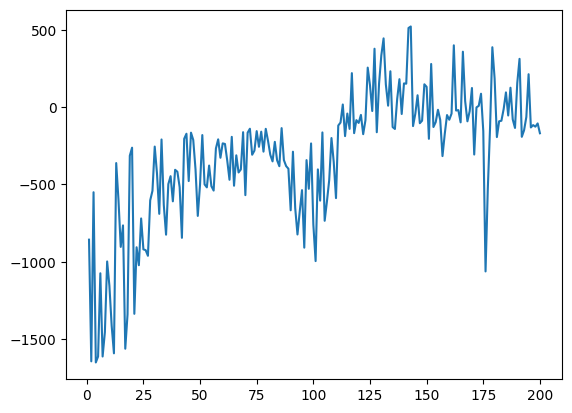

In [33]:
y = [item["reward"] / item["population"] for item in data]
x = [i+1 for i in range(len(y))]

plt.plot(x, y)
plt.show()

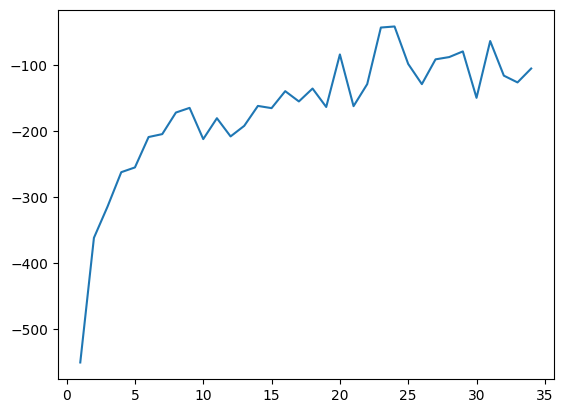

In [32]:
y = [item["reward"] / item["population"] for item in data if 1000 <= item["population"] <= 1300]
x = [i+1 for i in range(len(y))]

plt.plot(x, y)
plt.show()

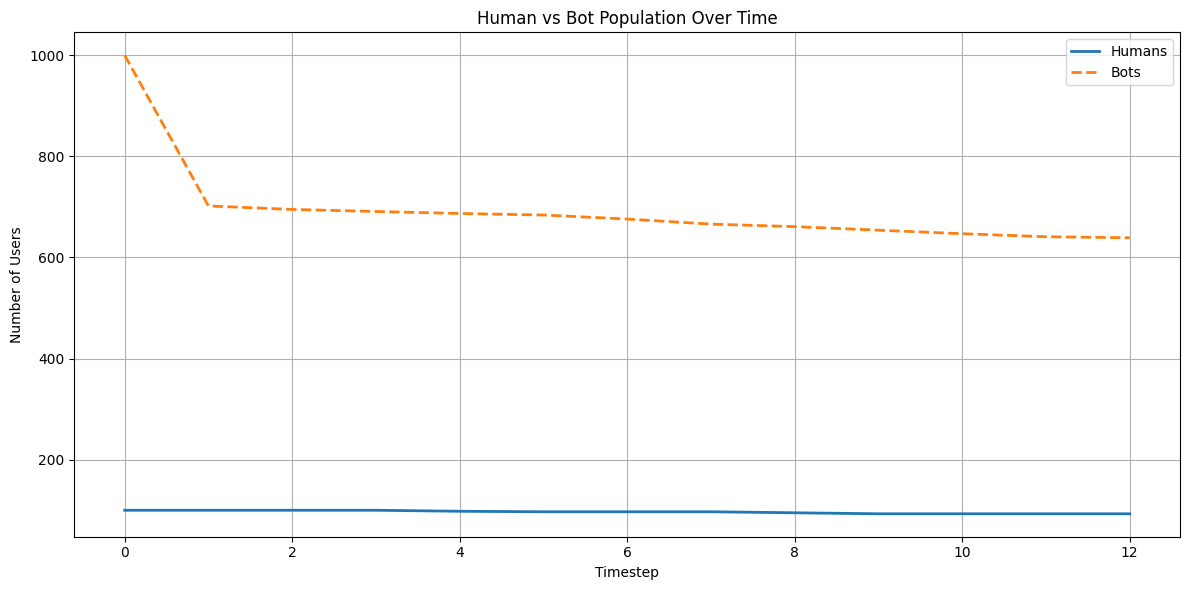

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

plt.plot(timestep_counts, human_counts,
         label="Humans",
         linestyle="-",
         linewidth=2)

plt.plot(timestep_counts, bot_counts,
         label="Bots",
         linestyle="--",
         linewidth=2)

plt.xlabel("Timestep")
plt.ylabel("Number of Users")
plt.title("Human vs Bot Population Over Time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()